# VEP Case Studies

Examplar results from the VEP pipeline investigating well-known disease-associated variants.

In [8]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.onekg as og

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First, let's count how many results we have for each model/scoring strategy.

In [2]:
vep_files = va.list_vep_files(as_df=True)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/3 [00:00<?, ?it/s]

Found 681511 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 85106
protein: 2142


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:793S>I,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:1106V>A,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


In [4]:
vep_files.sort_values(by=["model_location","scoring_strategy"]).groupby(["model_location","scoring_strategy"]).size()

model_location          scoring_strategy
esm1_t34_670M_UR50D     masked-marginals    85051
                        wt-marginals        85051
esm1_t6_43M_UR50S       masked-marginals      471
                        wt-marginals          487
esm1b_t33_650M_UR50S    masked-marginals    49938
                        wt-marginals        49938
esm1v_t33_650M_UR90S_1  masked-marginals    49944
                        wt-marginals        49944
esm2_t12_35M_UR50D      masked-marginals    85089
                        wt-marginals        85089
esm2_t33_650M_UR50D     masked-marginals    57984
                        pseudo-ppl             72
                        wt-marginals        57991
esm2_t48_15B_UR50D      masked-marginals    12229
                        wt-marginals        12233
dtype: int64

# Bottom-up: sort diseases by variance

In [6]:
vep_df = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[vep_files['model_location']=="esm2_t33_650M_UR50D"]
    )

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 57984 masked-marginals parquet files


Reading files:   0%|          | 0/57984 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 1.77GB/s]


VEP dataframe shape: (2028077, 72)


In [7]:
# Import haplotypes if not already defined
if 'haplotypes' not in locals():
    haplotypes = hs.get_haplotypes(
        tx_ids=vep_df['ENST'].unique().tolist(),
        cache_only=True
    )

# Add haplotype sequences to the VEP dataframe
vep_df = va.add_mutant_out_of_frame(vep_df, 
                                    haplotypes=haplotypes,
                                    force=True)

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/1450 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Getting haplotype sequences


Adding reference haplotype:   0%|          | 0/1450 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/1450 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1450 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Adding 'haplotype_sequence_len' column
Adding 'mutant_out_of_frame' column


In [6]:
vep_df = va.extract_id_cols(vep_df,
                             input_col="CLNDISDB",
                             search_terms=["MONDO"])
vep_df["MONDO_split"] = vep_df["MONDO"].apply(lambda x: [m.replace("MONDO:MONDO:", "MONDO:") for m in x] if isinstance(x, list) else [])
vep_df["MONDO"] = vep_df["MONDO_split"].str.join("|")

Extracting 1 ID column(s).
Extracting MONDO IDs.
Adding MONDO count column.


In [7]:
import src.owlready2 as OWL

onto = OWL.get_onto_mondo()
id_map = OWL.get_id_map(onto)

In [143]:
within_site_var, within_site_var_mean = va.get_mondo_within_site_var(vep_df=vep_df)
within_site_var.head()

,model_location,MONDO,MONDO_split,clinsig,protein,ENSP,GENEINFO,mutant,HGVSp,HGVSp_split,scoring_strategy,VEP,haplotype,MONDO_label
40027,esm2_t33_650M_UR50D,MONDO:0100464,MONDO:0100464,path,NP_000534.3,ENSP00000340409,SMPD1:6609,C223Y,NP_000534.3:p.Cys223Tyr,p.Cys223Tyr,masked-marginals,33.741302,101,acid sphingomyelinase deficiency
39259,esm2_t33_650M_UR50D,MONDO:0060760,MONDO:0060760,likely_path,NP_001177203.1,ENSP00000384823,FBXO11:80204,G665R,NP_001177203.1:p.Gly665Arg,p.Gly665Arg,masked-marginals,33.686699,17,intellectual developmental disorder with dysmo...
19733,esm2_t33_650M_UR50D,MONDO:0011871|MONDO:0009756,MONDO:0009756,likely_path,NP_000534.3,ENSP00000340409,SMPD1:6609,R498P,NP_000534.3:p.Arg498Pro,p.Arg498Pro,masked-marginals,31.947874,101,Niemann-Pick disease type A
19794,esm2_t33_650M_UR50D,MONDO:0011871|MONDO:0009756,MONDO:0011871,likely_path,NP_000534.3,ENSP00000340409,SMPD1:6609,R498P,NP_000534.3:p.Arg498Pro,p.Arg498Pro,masked-marginals,31.947874,101,Niemann-Pick disease type B
4382,esm2_t33_650M_UR50D,MONDO:0007042|MONDO:0007399,MONDO:0007399,path,NP_000465.1,ENSP00000242261,TWIST1:7291,R116P,NP_000465.1:p.Arg116Pro,p.Arg116Pro,masked-marginals,31.604641,9,TWIST1-related craniosynostosis


In [ ]:
va.plot_top_mondo(within_site_var_mean=within_site_var_mean,
                  vep_col="VEP",
                  label_col="MONDO_label",
                  hue="mutant",
                  palette="plasma",
                  max_label_length=70,
                  top_n=20,
                  figsize=(7, 8))

NameError: name 'va' is not defined

Transform the data from haplotype-level to individual-level

In [10]:
haplotypes = hs.get_haplotypes(cache_only=True,
                                tx_ids=vep_df['ENST'].unique()
                                ) 

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/1450 [00:00<?, ?it/s]

In [113]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes, 
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=True)
haps_to_samples.head()


Extracting sample IDs:   0%|          | 0/1450 [00:00<?, ?it/s]

Processing sample to haplotype name maps:   0%|          | 0/1450 [00:00<?, ?it/s]

<string>:69: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'None' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.


,sample,ENST_haplosaurus,haplotype,Gender,Population,Super Population
0,REF,ENST00000001146,ENSP00000001146:REF,None,REF,REF
5008,REF,ENST00000003084,ENSP00000003084:REF,None,REF,REF
10016,REF,ENST00000005257,ENSP00000005257:REF,None,REF,REF
15024,REF,ENST00000029410,ENSP00000029410:REF,None,REF,REF
20032,REF,ENST00000037502,ENSP00000037502:REF,None,REF,REF


Plot the Superpopulation-specific distributions for a single variant with the greatest amount of VEP spread.

Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations
Adding haplotype frequencies per population
Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    23
1000GENOMES:phase_3:EUR    15
1000GENOMES:phase_3:SAS    10
1000GENOMES:phase_3:EAS     9
1000GENOMES:phase_3:AMR     3
Name: count, dtype: int64

Percentage of population-specific haplotypes: 59.41%


<string>:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


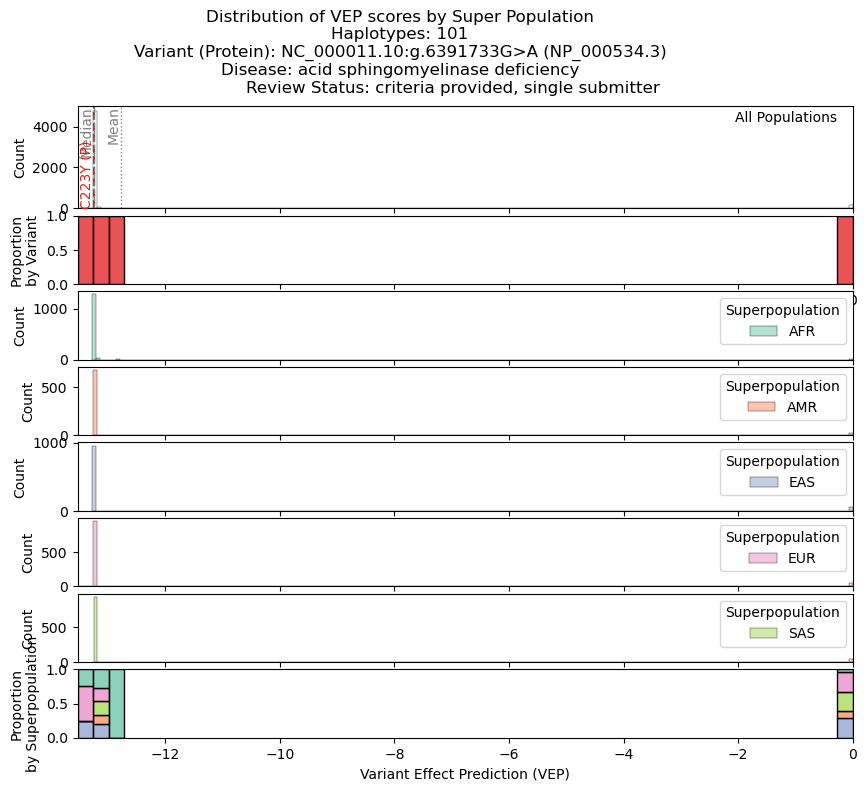

In [36]:
plot_df = va.plot_vep_by_superpop(vep_df=vep_df,
                                  remove_zeros=False, 
                                  within_site_var=within_site_var, 
                                  i=0,     
                                  legend_loc="upper right",
                                  hue_top="mutant",
                                  hue="Super Population",
                                  hue_bottom="Super Population",
                                  palette="Set1",
                                  haps_to_samples=haps_to_samples,
                                  unique_haplotypes = False)

### Top Niemann-Pick disease variants

In [39]:
npd_df = va.filter_top_mutants(vep_df=vep_df, 
                            within_site_var=within_site_var, 
                            search_col=["CLNDN","MONDO_label"],
                            search_terms=["sphingomyel","niemann-pick"])

5 top mutants selected


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations
Adding haplotype frequencies per population
Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    23
1000GENOMES:phase_3:EUR    15
1000GENOMES:phase_3:SAS    10
1000GENOMES:phase_3:EAS     9
1000GENOMES:phase_3:AMR     3
Name: count, dtype: int64

Percentage of population-specific haplotypes: 59.41%


<string>:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


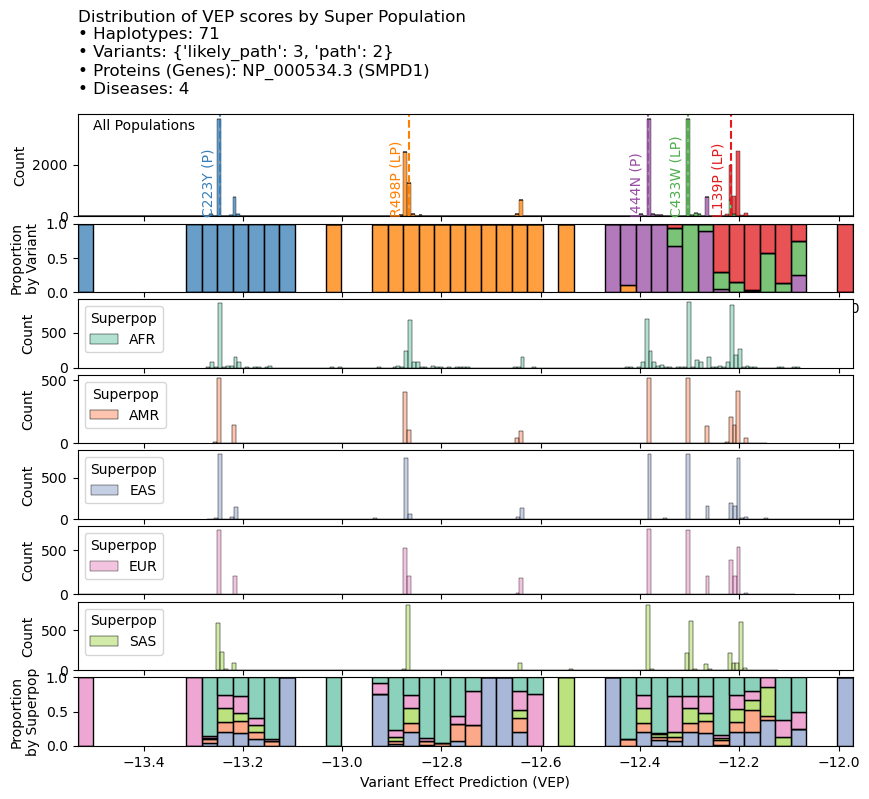

In [73]:
plot_df = va.plot_vep_by_superpop(vep_df=npd_df, 
                                  remove_zeros=True,
                                  within_site_var=within_site_var, 
                                  i=None,     
                                  haps_to_samples=haps_to_samples,
                                  figsize=(10, 8),
                                  palette="Set1", 
                                  hue_top="mutant",
                                  hue="Super Population", 
                                  hue_bottom="Super Population",
                                  
                                  unique_haplotypes = False)

### Top BRCA1 variants

In [85]:
brca_df = va.filter_top_mutants(vep_df=vep_df, 
                                within_site_var=within_site_var, 
                                search_col=["GENEINFO","GENEINFO"],
                                search_terms=["brca"], 
                                mutants_per_group=3)
brca_df["mutant"].unique()

12 top mutants selected


array(['L1839S', 'S1715N', 'V1687I', 'V1653L', 'R866C', 'R7L'],
      dtype=object)

Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations
Adding haplotype frequencies per population
Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    33
1000GENOMES:phase_3:SAS    17
1000GENOMES:phase_3:EAS    13
1000GENOMES:phase_3:AMR    13
1000GENOMES:phase_3:EUR    12
Name: count, dtype: int64

Percentage of population-specific haplotypes: 80.73%


<string>:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


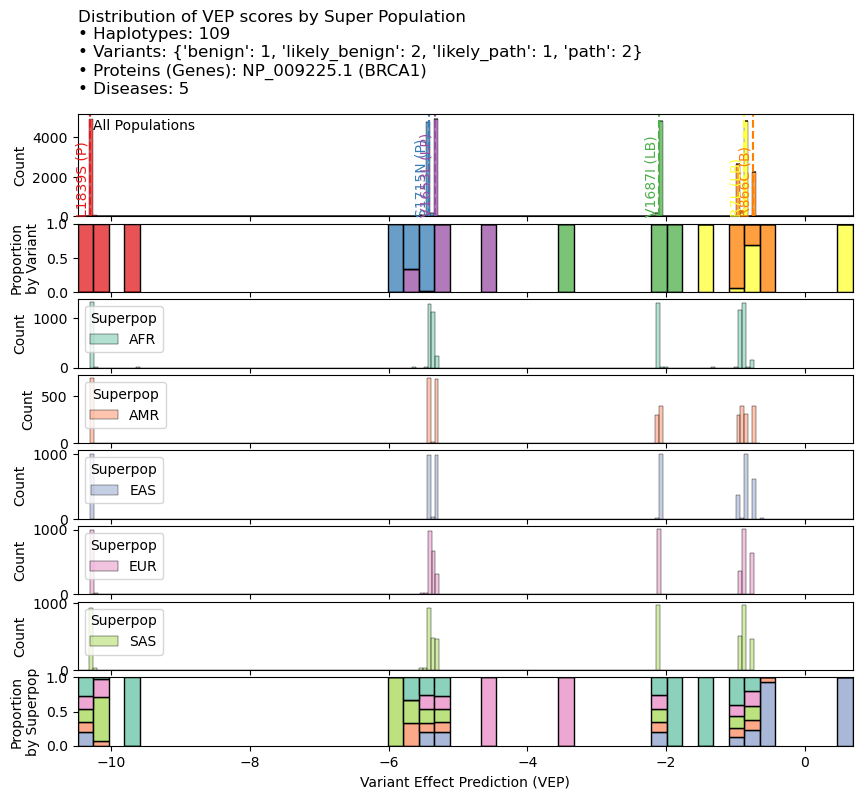

In [82]:
plot_df = va.plot_vep_by_superpop(vep_df=brca_df, 
                                  remove_zeros=False,
                                  within_site_var=within_site_var, 
                                  i=None,     
                                  haps_to_samples=haps_to_samples,
                                  figsize=(10, 8), 
                                  palette="Set1", 
                                  hue_top="mutant",
                                  hue="Super Population", 
                                  hue_bottom="Super Population",
                                  
                                  unique_haplotypes = False)

### Validate using ProteinGym DMS data

In [42]:
dms_files = pg.merge_resources(keys=['DMS_ProteinGym_substitutions.zip'],
                                map_ids=False)
dms_files['gene'] = dms_files["protein"].str.split("_").str[0]
print(dms_files.shape)
dms_files.head()

ProteinGym: Gathering resources:   0%|          | 0/1 [00:00<?, ?it/s]

(217, 6)


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,gene
0,ARGR_ECOLI_Tsuboyama_2023_1AOY,ARGR_ECOLI_Tsuboyama_2023_1AOY,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions,DMS_ProteinGym_substitutions/ARGR_ECOLI_Tsuboy...,ARGR
1,UBE4B_MOUSE_Starita_2013,UBE4B_MOUSE_Starita_2013,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions,DMS_ProteinGym_substitutions/UBE4B_MOUSE_Stari...,UBE4B
2,Q6WV12_9MAXI_Somermeyer_2022,Q6WV12_9MAXI_Somermeyer_2022,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions,DMS_ProteinGym_substitutions/Q6WV12_9MAXI_Some...,Q6WV12
3,Q8WTC7_9CNID_Somermeyer_2022,Q8WTC7_9CNID_Somermeyer_2022,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions,DMS_ProteinGym_substitutions/Q8WTC7_9CNID_Some...,Q8WTC7
4,OBSCN_HUMAN_Tsuboyama_2023_1V1C,OBSCN_HUMAN_Tsuboyama_2023_1V1C,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions,DMS_ProteinGym_substitutions/OBSCN_HUMAN_Tsubo...,OBSCN


In [10]:
sorted(dms_files["gene"].unique())
dms_brca1 = pd.concat([pd.read_csv(f).assign(source_file=f) for f in dms_files.loc[dms_files["gene"]=="BRCA1"].source_file])
dms_brca1.head()
### Top Oak 2020 variants

,mutant,mutated_sequence,DMS_score,DMS_score_bin,source_file
0,M1I,IDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,-2.502128,0,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...
1,M1V,VDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,-2.025645,0,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...
2,M1T,TDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,-1.656569,0,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...
3,M1R,RDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,-2.481580,0,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...
4,M1L,LDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,-2.516529,0,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...


In [11]:
vep_brca1 = va.merge_vep(
    # scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[vep_files['protein']=='NP_009225.1']
)
vep_brca1 = vep_df.loc[vep_df["GENEINFO"].str.contains("BRCA1")].merge(dms_brca1, on="mutant", how="inner")
vep_brca1.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 546 wt-marginals parquet files


Reading files:   0%|          | 0/546 [00:00<?, ?it/s]

Found 546 masked-marginals parquet files


Reading files:   0%|          | 0/546 [00:00<?, ?it/s]

Found 0 pseudo-ppl parquet files
Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 5.01GB/s]


VEP dataframe shape: (497952, 72)


,haplotype,protein,protein_sequence,mutant,mutated_sequence_x,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,haplotype_sequence_len_pct,mutant_out_of_frame,mutated_sequence_y,DMS_score,DMS_score_bin,source_file
0,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Y1853C,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-5.726666,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045712,55627,T,C,.,PASS,55627,17:43045712,C,672,NM_007294.4,Transcript,missense_variant,5671,5558,1853,Y/C,tAc/tGc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_007294.4:c.5558A>G,NP_009225.1:p.Tyr1853Cys,-,NaN,NaN,70294,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Stomac...,NC_000017.11:g.43045712T>C,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357258,NaN,ClinGen:CA003714,NaN,NaN,NaN,NaN,NaN,-3.363384,NaN,5,likely_path,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,1863,1863.0,1.0,False,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,-2.763438,0,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...
1,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Y1853S,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-6.557245,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045712,865016,T,G,.,PASS,865016,17:43045712,G,672,NM_007294.4,Transcript,missense_variant,5671,5558,1853,Y/S,tAc/tCc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_007294.4:c.5558A>C,NP_009225.1:p.Tyr1853Ser,-,NaN,NaN,853086,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Breast...,NC_000017.11:g.43045712T>G,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.971179,NaN,5,likely_path,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,1863,1863.0,1.0,False,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,-1.698237,0,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...
2,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Y1853H,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,0.481865,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045713,865014,A,G,.,PASS,865014,17:43045713,G,672,NM_007294.4,Transcript,missense_variant,5670,5557,1853,Y/H,Tac/Cac,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.5557T>C,NP_009225.1:p.Tyr1853His,-,NaN,NaN,853088,"MONDO:MONDO:0003582,MeSH:D061325,MedGen:C06777...",Hereditary_breast_ovarian_cancer_syndrome|Brea...,NC_000017.11:g.43045713A>G,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,2050860958,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.225666,NaN,5,likely_path,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,1863,1863.0,1.0,False,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,-1.652883,0,/home/schilder/.cache/ProteinGym/DMS_ProteinG

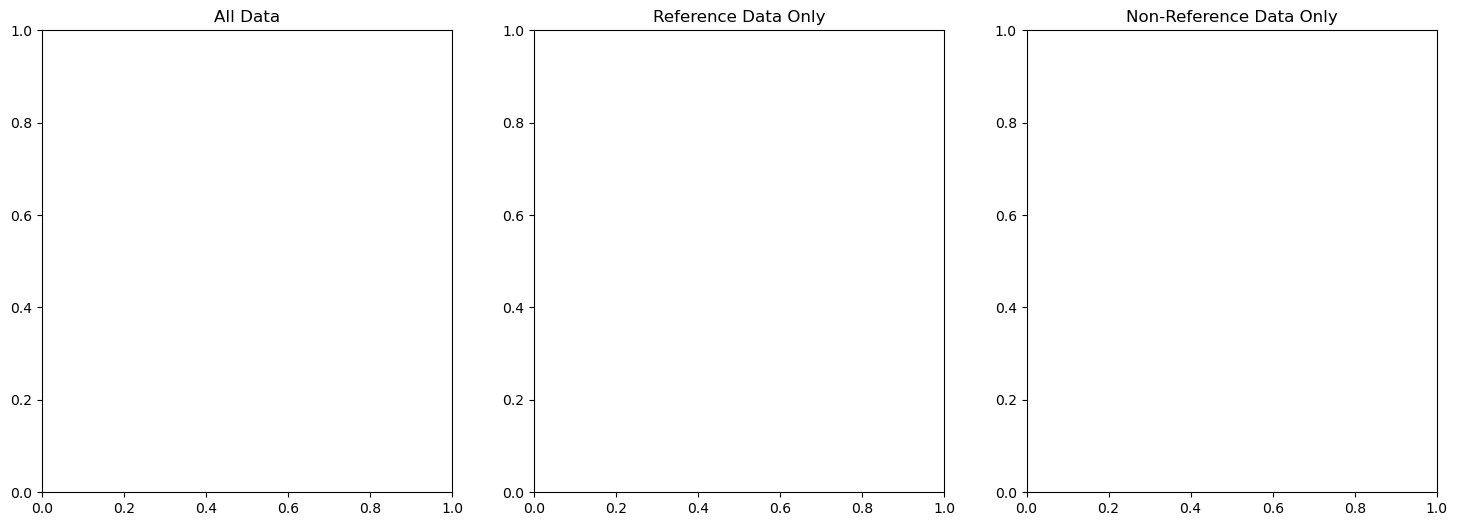

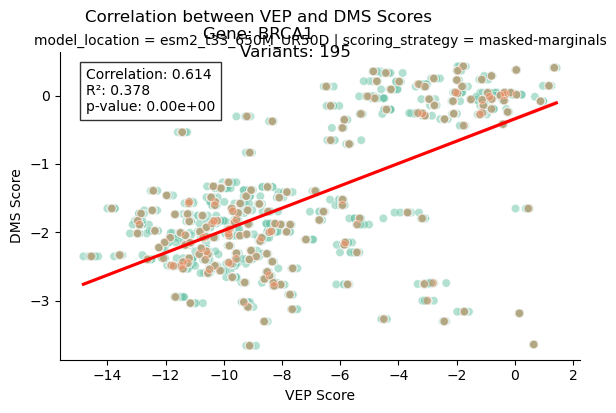

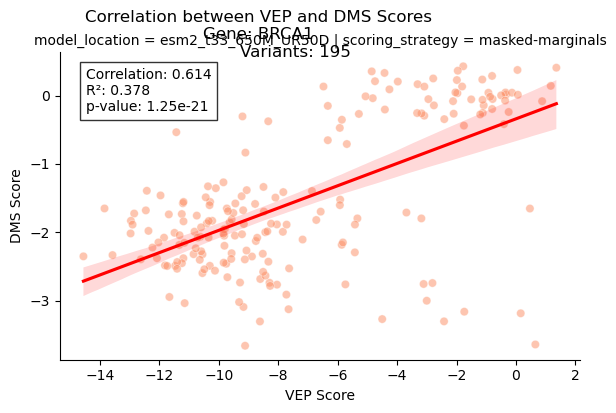

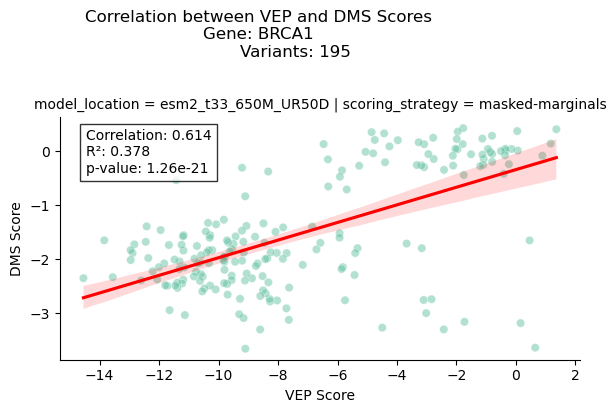

In [19]:

import matplotlib.pyplot as plt

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap = utils.make_palette(vep_brca1["is_ref"].unique().tolist(),
                                     palette="Set2")
# Plot all data
va.plot_vep_dms_correlation(vep_brca1, ax=axes[0], cmap=cmap)
axes[0].set_title("All Data")

# Plot reference data only
ref_data = vep_brca1[vep_brca1['is_ref'] == True]
va.plot_vep_dms_correlation(ref_data, ax=axes[1], cmap=cmap)
axes[1].set_title("Reference Data Only")

# Plot non-reference data only
non_ref_data = vep_brca1[vep_brca1['is_ref'] == False]
non_ref_data  = non_ref_data.groupby(["model_location","scoring_strategy","GENEINFO","mutant"]).agg({"VEP": "mean", "DMS_score": "mean"}).sort_values("VEP", ascending=False).reset_index()
non_ref_data["is_ref"] = False
va.plot_vep_dms_correlation(non_ref_data, ax=axes[2], cmap=cmap)
axes[2].set_title("Non-Reference Data Only")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'VEP Scores by DMS Score Bin and Reference Status\nwith Statistical Significance')

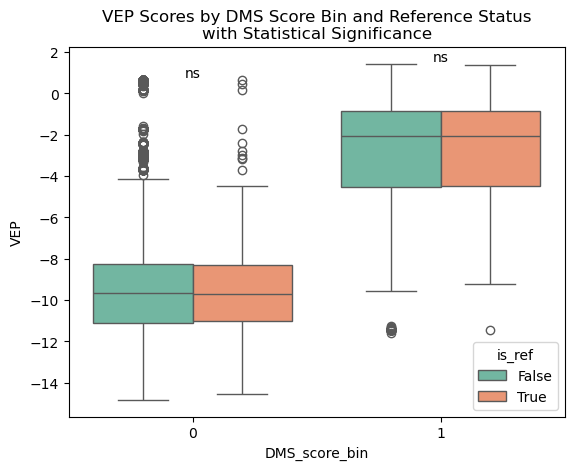

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Create boxplot
ax = sns.boxplot(data=vep_brca1, x="DMS_score_bin", y="VEP", hue="is_ref", palette=cmap)

# Add statistical significance testing
for bin_val in vep_brca1["DMS_score_bin"].unique():
    bin_data = vep_brca1[vep_brca1["DMS_score_bin"] == bin_val]
    ref_data = bin_data[bin_data["is_ref"] == True]["VEP"]
    non_ref_data = bin_data[bin_data["is_ref"] == False]["VEP"]
    
    # Perform Mann-Whitney U test
    stat, pval = stats.mannwhitneyu(ref_data, non_ref_data, alternative='two-sided')
    
    # Add significance stars
    y_max = max(ref_data.max(), non_ref_data.max())
    if pval < 0.001:
        sig = '***'
    elif pval < 0.01:
        sig = '**'
    elif pval < 0.05:
        sig = '*'
    else:
        sig = 'ns'
        
    ax.text(bin_val, y_max + 0.1, sig, ha='center')

plt.title("VEP Scores by DMS Score Bin and Reference Status\nwith Statistical Significance")

### All DMS

In [44]:
sorted(dms_files["gene"].unique())
from tqdm import tqdm

dms = []
for i,row in tqdm(dms_files.iterrows(), 
                  total=len(dms_files),
                  desc="Reading DMS files"):
    df = pd.read_csv(row["source_file"])
    df['gene'] = row["gene"]
    df['source_file'] = row["source_file"]
    df["experiment_id"] = row["experiment_id"]
    df["source_type"] = row["source_type"]
    dms.append(df)
dms = pd.concat(dms)
print(dms.shape)
dms.head()


Reading DMS files:   0%|          | 0/217 [00:00<?, ?it/s]

Reading DMS files: 100%|██████████| 217/217 [00:08<00:00, 25.82it/s]


(2465767, 9)


,mutant,mutated_sequence,DMS_score,DMS_score_bin,gene,source_file,experiment_id,source_type,DMS_bin_score
0,A10C,QEELVKAFKCLLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-0.612124,0,ARGR,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions/ARGR_ECOLI_Tsuboy...,DMS_ProteinGym_substitutions,NaN
1,A10D,QEELVKAFKDLLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-0.330434,1,ARGR,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions/ARGR_ECOLI_Tsuboy...,DMS_ProteinGym_substitutions,NaN
2,A10E,QEELVKAFKELLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-0.213194,1,ARGR,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions/ARGR_ECOLI_Tsuboy...,DMS_ProteinGym_substitutions,NaN
3,A10F,QEELVKAFKFLLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-0.371293,1,ARGR,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions/ARGR_ECOLI_Tsuboy...,DMS_ProteinGym_substitutions,NaN
4,A10G,QEELVKAFKGLLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,-0.312110,1,ARGR,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions/ARGR_ECOLI_Tsuboy...,DMS_ProteinGym_substitutions,NaN


In [ ]:
# vep_dms = hs.add_haplotype_freqs(vep_dms)

haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes, 
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=True)
haps_to_samples.head()

Extracting sample IDs:   0%|          | 0/1450 [00:00<?, ?it/s]

Processing sample to haplotype name maps:   0%|          | 0/1450 [00:00<?, ?it/s]

In [242]:
vep_df["gene"] = vep_df["GENEINFO"].str.split(":").str[0]

# Add DMSinformation
vep_dms = vep_df.merge(dms, on=["gene","mutant"], how="inner")
print(vep_dms.shape)
vep_dms.head()

# Add haplotype information
vep_dms = haps_to_samples.merge(vep_dms, on="haplotype", how="inner")
vep_dms["is_ref"]  = vep_dms["Super Population"] == "REF"
vep_dms["clinsig"] = vep_dms["CLNSIG"].map(pg.CLINSIG_MAP)
print(vep_dms.shape)
vep_dms.head()


(26144, 128)
(1527745, 133)


,sample,ENST_haplosaurus,haplotype,Gender,Population,Super Population,protein,protein_sequence,mutant,mutated_sequence_x,DMS_bin_score_x,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,haplotype_sequence_len_pct,mutant_out_of_frame,gene,freq_1000GENOMES:phase_3:ASW,freq_all,freq_1000GENOMES:phase_3:EAS,freq_1000GENOMES:phase_3:PEL,freq_1000GENOMES:phase_3:LWK,freq_1000GENOMES:phase_3:KHV,freq_GGVP:GWJ,freq_1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:CEU,freq_GGVP:GWF,freq_1000GENOMES:phase_3:MSL,freq_1000GENOMES:phase_3:BEB,freq_1000GENOMES:phase_3:ESN,freq_1000GENOMES:phase_3:CHB,freq_1000GENOMES:phase_3:IBS,freq_GGVP:GWD,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:ITU,freq_GGVP:GWW,freq_1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:GWD,freq_1000GENOMES:phase_3:GBR,freq_1000GENOMES:phase_3:CDX,freq_1000GENOMES:phase_3:STU,freq_1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:EUR,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:AMR,freq_1000GENOMES:phase_3:FIN,freq_1000GENOMES:phase_3:ACB,freq_1000GENOMES:phase_3:AFR,freq_1000GENOMES:phase_3:MXL,freq_1000GENOMES:phase_3:YRI,freq_1000GENOMES:phase_3:ALL,freq_1000GENOMES:phase_3:JPT,freq_GGVP:ALL,top_pop,top_superpop,top_superpop_freq,nonzero_superpop_freqs,specific_superpopulation,mutated_sequence_y,DMS_score,DMS_score_bin,source_file,experiment_id,source_type,DMS_bin_score_y
0,REF,ENST00000262186,ENSP00000262186:REF,None,REF,REF,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L552S,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-5.656371,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150951738,67225,A,G,.,PASS,67225,7:150951738,G,3757,NM_000238.4,Transcript,missense_variant,2063,1655,552,L/S,tTg/tCg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_000238.4:c.1655T>C,NP_000229.1:p.Leu552Ser,-,NaN,0.00004,78121,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Cardi...,NC_000007.14:g.150951738A>G,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199472918,0.00020,ClinGen:CA004960|UniProtKB:Q12809#VAR_008918,NaN,NaN,NaN,NaN,NaN,-12.312705,-0.022626,6,path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,KCNH2,0.918033,0.866235,0.934524,0.923529,0.979798,0.89899,1,0.947619,0.70202,1,0.976471,0.680233,0.964646,0.961165,0.71028,1,0.754808,0.715686,1,0.771277,0.982301,0.703297,0.908602,0.764706,0.73301,0.686916,0.735174,0.700795,0.776042,0.811239,0.70202,0.927083,0.963691,0.8125,0.976852,0.839257,0.951923,1,GGVP:GWJ,freq_1000GENOMES:phase_3:AFR,0.963691,5.0,None,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,25.146344,0,/home/schilder/.cache/ProteinGym/DMS_ProteinGy...,DMS_ProteinGym_substitutions/KCNH2_HUMAN_Kozek...,DMS_ProteinGym_substitutions,NaN
1,REF,ENST00000268124,ENSP00000268124:REF,None,REF,REF,NP_002684.1,MSRLLWRKVAGATVGPGPVPAPGRWVSSSVPASDPSDGQRRRQQQQ...,T851A,MSRLLWRKVAGATVGPGPVPAPGRWVSSSVPASDPSDGQRRRQQQQ...,Pathogenic,-7.820432,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000268124,ENST00000268124,False,15,89321783,619395,T,C,.,PASS,619395,15:89321783,C,5428,NM_002693.3,Transcript,missens

In [243]:
corr_res = {}
groupby_cols = ["model_location","scoring_strategy","gene","experiment_id","is_ref","Super Population","clinsig"]
for group_name, group_data in vep_dms.groupby(groupby_cols):
    corr = group_data["VEP"].corr(group_data["DMS_score"], method="spearman")
    corr_res[group_name] = abs(corr)

corr_res = pd.DataFrame(corr_res, index=["corr"]).T.reset_index()
corr_res.columns = groupby_cols + ["corr"]
print(corr_res.shape)
corr_res.head()

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


(186, 8)


,model_location,scoring_strategy,gene,experiment_id,is_ref,Super Population,clinsig,corr
0,esm2_t33_650M_UR50D,masked-marginals,BRCA1,DMS_ProteinGym_substitutions/BRCA1_HUMAN_Findl...,False,AFR,benign,0.199585
1,esm2_t33_650M_UR50D,masked-marginals,BRCA1,DMS_ProteinGym_substitutions/BRCA1_HUMAN_Findl...,False,AFR,likely_benign,0.369502
2,esm2_t33_650M_UR50D,masked-marginals,BRCA1,DMS_ProteinGym_substitutions/BRCA1_HUMAN_Findl...,False,AFR,likely_path,0.036090
3,esm2_t33_650M_UR50D,masked-marginals,BRCA1,DMS_ProteinGym_substitutions/BRCA1_HUMAN_Findl...,False,AFR,path,0.218459
4,esm2_t33_650M_UR50D,masked-marginals,BRCA1,DMS_ProteinGym_substitutions/BRCA1_HUMAN_Findl...,False,AMR,benign,0.198633


Text(0, 0.5, 'VEP vs. DMS correlations (Spearman)')

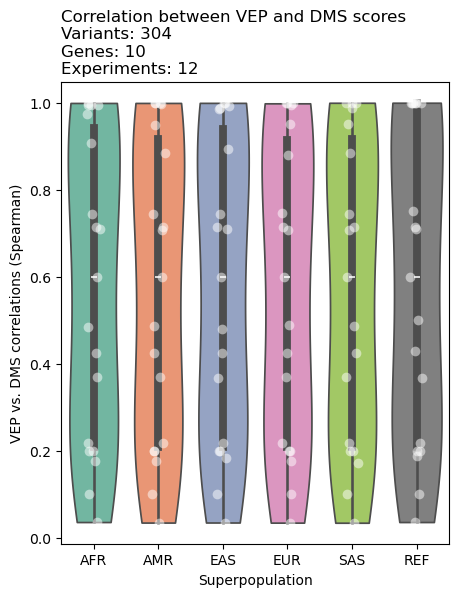

In [ ]:
plt.figure(figsize=(5, 6))  # Made width smaller (5 instead of default)
sns.violinplot(data=corr_res,
             x="Super Population", y="corr", hue="Super Population",
             cut=0,
             palette=utils.get_superpop_palette())
sns.stripplot(data=corr_res,
             x="Super Population", y="corr",
             color="white", alpha=0.5, size=7)
plt.title(f"Correlation between VEP and DMS scores\n\
Variants: {vep_dms['mutant'].nunique()}\n\
Genes: {vep_dms['gene'].nunique()}\n\
Experiments: {vep_dms['experiment_id'].nunique()}", 
x=0, ha='left')
plt.xlabel("Superpopulation")
plt.ylabel("VEP vs. DMS correlations (Spearman)") 

AttributeError: 'DataFrame' object has no attribute 'mutant'

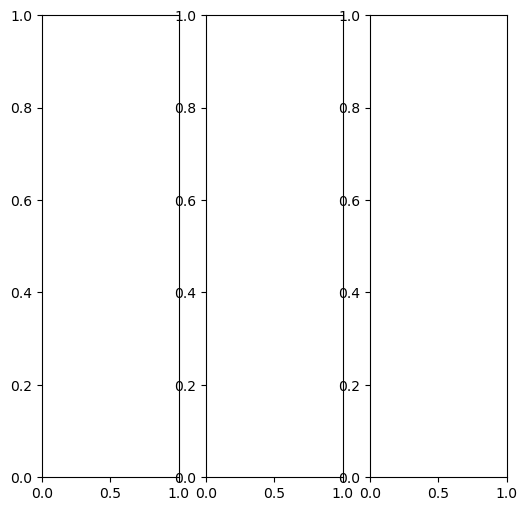

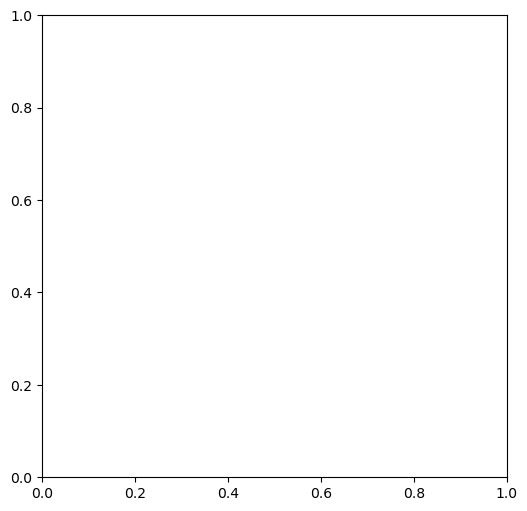

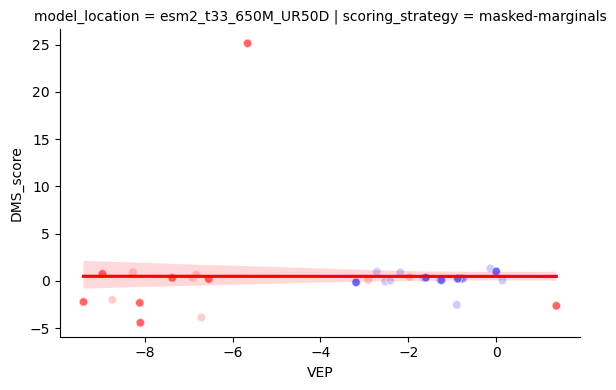

In [252]:
vep_dma_agg = vep_dms.groupby(["model_location","scoring_strategy","gene",
                               "is_ref","clinsig","Super Population"]
                               ).agg({"VEP": "mean","DMS_score": "mean"}).reset_index()
 

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(6, 6))
cmap = utils.get_clinsig_palette()
# Plot all data
va.plot_vep_dms_correlation(vep_dma_agg,  cmap=cmap,
                            hue="clinsig")
axes[0].set_title("All Data")

# Plot reference data only
ref_data = vep_dma_agg[vep_dma_agg['is_ref'] == True]
va.plot_vep_dms_correlation(ref_data, ax=axes[1], cmap=cmap,
                            hue="clinsig")
axes[1].set_title("Reference Data Only")

# Plot non-reference data only
non_ref_data = vep_dma_agg[vep_dma_agg['is_ref'] == False]
va.plot_vep_dms_correlation(non_ref_data, ax=axes[2], cmap=cmap,
                            hue="clinsig")
axes[2].set_title("Non-Reference Data Only")

plt.tight_layout()
plt.show()

### Top Oak 2020 variants

In [ ]:
import src.Oak2020 as o2

s4a = o2.read_supp_data(sheet_name='S4a.PredisposingVariants')
s4b = o2.read_supp_data(sheet_name='S4b.SomaticSecondHit') 

In [145]:
vep_df["HGVSp_split"].unique

<bound method Series.unique of 0          p.Leu1045Phe
1          p.Asp1003Tyr
2           p.Asn996Ile
3           p.Glu978Lys
4           p.Pro967Leu
               ...     
2028072     p.His353Tyr
2028073     p.Pro351Ala
2028074     p.Glu162Lys
2028075      p.Val75Ile
2028076      p.Lys66Arg
Name: HGVSp_split, Length: 2028077, dtype: object>

In [146]:
s4a =  s4a.loc[(s4a["VARIANT_CLASS"] == "SNV") &\
             (s4a['Variant_Classification'].str.contains("missense_variant|stop_gained"))] 
s4a["HGVSp_split"] = s4a["HGVSp.1"].str.split(":").str[1]
print(s4a.shape)



(8, 131)


array(['p.Arg3128Ter', 'p.Arg3008Cys', 'p.Ser187Ter', 'p.Tyr27Asn',
       'p.Arg46Ter', 'p.Cys162Phe', 'p.Glu2137Ter'], dtype=object)

In [158]:
vep_df.loc[vep_df["HGVSp_split"].isin(s4a["HGVSp_split"].unique().tolist())]


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,haplotype_sequence_len_pct,mutant_out_of_frame,MONDO,MONDO_n,MONDO_split,HGVSp.1,HGVSp_split


In [159]:
vep_df.loc[vep_df["HGVSp_split"].isin(s4b["Germline Variant"].unique().tolist())]

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,haplotype_sequence_len_pct,mutant_out_of_frame,MONDO,MONDO_n,MONDO_split,HGVSp.1,HGVSp_split


In [160]:
oak_df = va.filter_top_mutants(vep_df=vep_df, 
                                within_site_var=within_site_var, 
                                search_col=["HGVSp_split","HGVSp_split"],
                                search_terms=s4a["HGVSp_split"].unique(), 
                                mutants_per_group=3)
# oak_df["mutant"].unique()

0 top mutants selected


No overlap between ProteinGym missense variants and Oak2022 cancer predisposition variants....

# Top-down: candidate protein-focused

In [5]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins.loc[candidate_proteins['RefSeq Protein'].isin(vep_files['protein'])]

,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,ENSP,RefSeq Protein Stable
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,ENSP00000417404,NP_000401
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,ENSP00000003084,NP_000483
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,ENSP00000350283,NP_009225
5,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,ENSP00000356771,NP_000121
6,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,ENSP00000333994,NP_000509
7,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,ENSP00000376802,NP_000286
8,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,ENSP00000454071,NP_000518
9,KCNQ1,Potassium Voltage-Gated Channel Subfamily Q Me...,NP_000209.2,NM_000218.3,ENSP00000155840,NP_000209
10,KCNH2,Potassium Voltage-Gated Channel Subfamily H Me...,NP_000229.1,NM_000238.4,ENSP00000262186,NP_000229


## BRCA1

In [6]:
gene = "BRCA1"
brca1 = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['protein'].isin(
        candidate_proteins.loc[candidate_proteins['Gene']==gene]['RefSeq Protein']
            ))]
            )

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 437 masked-marginals parquet files


Reading files:   0%|          | 0/437 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 5.40GB/s]
/home/schilder/projects/VEP_protein/src/vep_analysis.py:201: DtypeWarning: Columns (0,47) have mixed types. Specify dtype option on import or set low_memory=False.
  pgd_subs_raw = pd.read_csv(pgd_resources['substitutions_raw_clinical'][0])


VEP dataframe shape: (199272, 72)


In [7]:
brca1 = hs.add_haplotype_freqs(brca1) 

Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations


Adding haplotype frequencies per population:   0%|          | 0/32 [00:00<?, ?it/s]

In [8]:
brca1.head()

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,freq_1000GENOMES:phase_3:ACB,freq_1000GENOMES:phase_3:AFR,freq_1000GENOMES:phase_3:ALL,freq_1000GENOMES:phase_3:AMR,freq_1000GENOMES:phase_3:ASW,freq_1000GENOMES:phase_3:BEB,freq_1000GENOMES:phase_3:CDX,freq_1000GENOMES:phase_3:CEU,freq_1000GENOMES:phase_3:CHB,freq_1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:EAS,freq_1000GENOMES:phase_3:ESN,freq_1000GENOMES:phase_3:EUR,freq_1000GENOMES:phase_3:FIN,freq_1000GENOMES:phase_3:GBR,freq_1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:GWD,freq_1000GENOMES:phase_3:IBS,freq_1000GENOMES:phase_3:ITU,freq_1000GENOMES:phase_3:JPT,freq_1000GENOMES:phase_3:KHV,freq_1000GENOMES:phase_3:LWK,freq_1000GENOMES:phase_3:MSL,freq_1000GENOMES:phase_3:MXL,freq_1000GENOMES:phase_3:PEL,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:STU,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:YRI,top_pop,top_superpop,top_superpop_freq
0,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,H1860Q,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.549707,masked-marginals,False,esm2_t12_35M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045690,1748423,G,T,.,PASS,1748423,17:43045690,T,672,NM_007294.4,Transcript,missense_variant,5693,5580,1860,H/Q,caC/caA,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5580C>A,NP_009225.1:p.His1860Gln,-,NaN,NaN,1806671,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.43045690G>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632517,NaN,5,likely_benign,NaN,NaN,0.000799,0.005764,NaN,NaN,NaN,NaN,NaN,NaN,0.021277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:AMR,0.005764
1,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1859R,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,-0.585173,masked-marginals,False,esm2_t12_35M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045694,55634,G,C,.,PASS,55634,17:43045694,C,672,NM_007294.4,Transcript,missense_variant,5689,5576,1859,P/R,cCc/cGc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5576C>G,NP_009225.1:p.Pro1859Arg,-,NaN,0.00002,70301,"MedGen:CN517202|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.43045694G>C,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357322.0,NaN,BRCA1-HCI:BRCA1_00098|ClinGen:CA003729,NaN,NaN,NaN,NaN,NaN,-0.490676,NaN,5,benign,NaN,NaN,0.000799,0.005764,NaN,NaN,NaN,NaN,NaN,NaN,0.021277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:AMR,0.005764
2,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,I1858L,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.533678,masked-marginals,False,esm2_t12_35M_UR50D,clinical_ProteinGym_substitutions,ENSP0

In [9]:
print(brca1.groupby(['top_superpop'])['haplotype'].nunique().sort_values(ascending=False))
print(brca1.groupby(['top_pop'])['haplotype'].nunique().sort_values(ascending=False))

top_superpop
freq_1000GENOMES:phase_3:AFR    39
freq_1000GENOMES:phase_3:SAS    19
freq_1000GENOMES:phase_3:AMR    18
freq_1000GENOMES:phase_3:EUR    17
freq_1000GENOMES:phase_3:EAS    16
Name: haplotype, dtype: int64
top_pop
1000GENOMES:phase_3:ACB    7
1000GENOMES:phase_3:LWK    7
1000GENOMES:phase_3:MSL    7
1000GENOMES:phase_3:PUR    6
1000GENOMES:phase_3:CDX    6
1000GENOMES:phase_3:ASW    6
1000GENOMES:phase_3:TSI    6
1000GENOMES:phase_3:CEU    5
1000GENOMES:phase_3:CLM    5
1000GENOMES:phase_3:YRI    5
1000GENOMES:phase_3:JPT    5
1000GENOMES:phase_3:GIH    5
1000GENOMES:phase_3:GWD    5
1000GENOMES:phase_3:MXL    4
1000GENOMES:phase_3:ESN    4
1000GENOMES:phase_3:PJL    4
1000GENOMES:phase_3:STU    4
1000GENOMES:phase_3:ITU    4
1000GENOMES:phase_3:CHB    3
1000GENOMES:phase_3:IBS    2
1000GENOMES:phase_3:BEB    2
1000GENOMES:phase_3:FIN    2
1000GENOMES:phase_3:PEL    2
1000GENOMES:phase_3:CHS    1
1000GENOMES:phase_3:KHV    1
1000GENOMES:phase_3:GBR    1
Name: haplotype, dty

In [10]:
brca1.haplotype.nunique()

109

In [11]:
brca1.mutant.nunique()

456

### VEP by top superpopulation (unweighted)

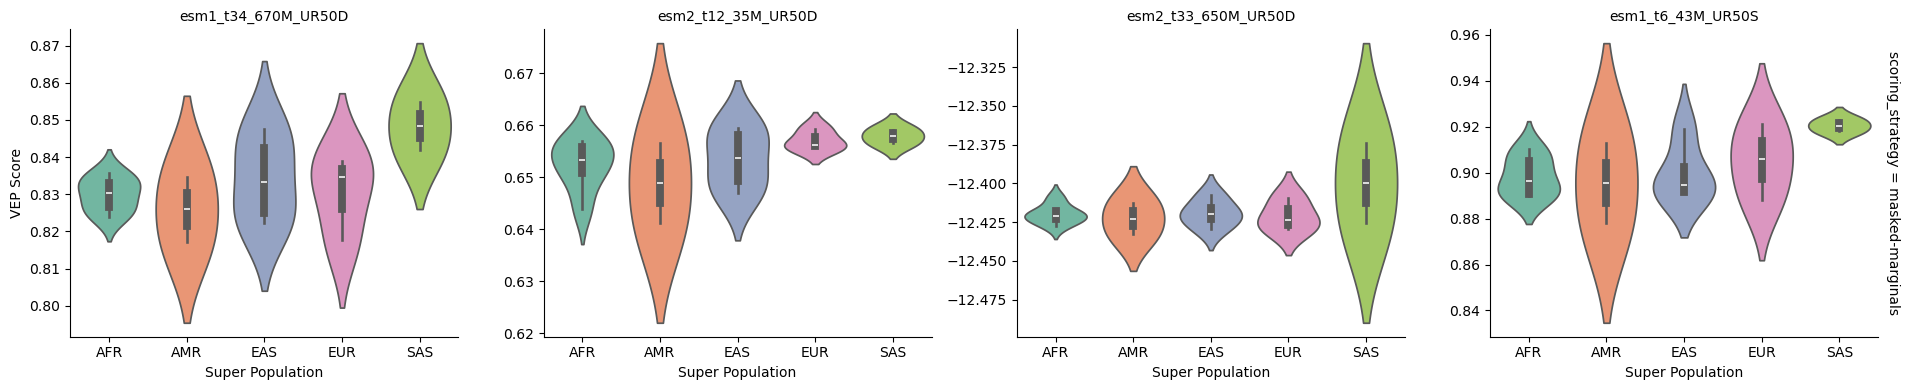

In [12]:
va.plot_population_vep_violin_unweighted(brca1, mutant="M1775R", min_freq=0.005)


### VEP by top superpopulation (weighted by superpopulation-specific haplotype frequency)

In [13]:
fig = va.plot_population_vep_violin_weighted(brca1, 
                                               mutant="M1775R", 
                                               min_freq=0.005)

KeyError: ['frequency']

### VEP by superpopulation (weighted by ALL haplotype frequencies)

In [14]:
# Get frequencies for every population (or superpopulation), not just the top one per haplotype
brca1_freq = va.create_vep_frequency_df(brca1, 
                                        pop_col= "Super Population")

(996360, 7)


In [15]:
brca1_freq.loc[brca1_freq['mutant']=="M1775R"].dropna(subset=['frequency','VEP']).sort_values(by=['VEP','frequency'], ascending=[True,False]).groupby(['model_location','scoring_strategy','mutant']).head(1)

,haplotype,model_location,scoring_strategy,mutant,VEP,frequency,Super Population
58871,ENSP00000350283:1710G>R,esm2_t33_650M_UR50D,masked-marginals,M1775R,-12.510061,0.001022,SAS
47015,"ENSP00000350283:871P>L,1645R>T",esm2_t12_35M_UR50D,masked-marginals,M1775R,0.633497,0.000756,AFR
119063,ENSP00000350283:466R>Q,esm1_t34_670M_UR50D,masked-marginals,M1775R,0.796746,0.001441,AMR
154631,ENSP00000350283:1347R>G,esm1_t6_43M_UR50S,masked-marginals,M1775R,0.874597,0.002882,AMR


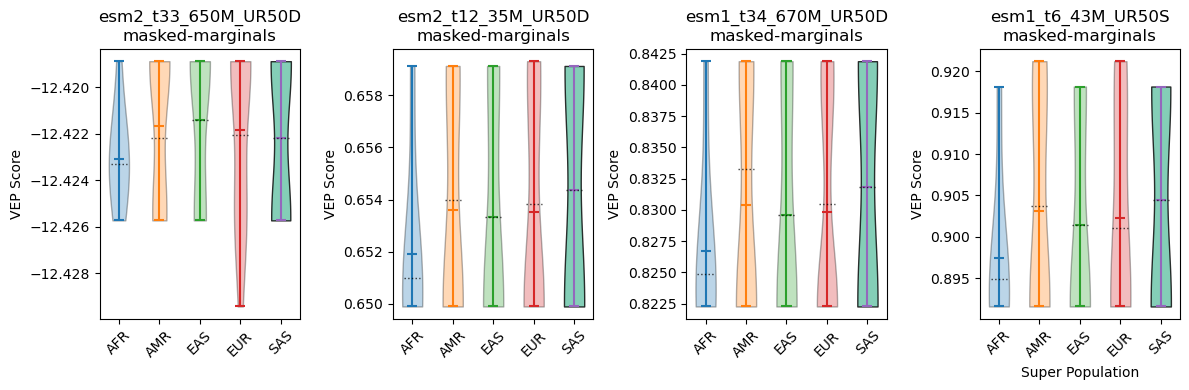

In [25]:
fig = va.plot_population_vep_violin_weighted(brca1_freq,
                                             top_pop_col='Super Population',
                                             mutant="M1775R", 
                                             min_freq=0, 
                                             log_fold_change=False)

## APOE

In [ ]:
# APOE-ε2 (cys112, cys158)
# APOE-ε3 (cys112, arg158)
# APOE-ε4 (arg112, arg158)

## HBB

In [31]:
gene = "HBB" # "SERPINA1"
hbb = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['protein'].isin(
        candidate_proteins.loc[candidate_proteins['Gene']==gene]['RefSeq Protein']
            ))]
            )

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 225 masked-marginals parquet files


Reading files:   0%|          | 0/225 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 4.96GB/s]
/home/schilder/projects/VEP_protein/src/vep_analysis.py:201: DtypeWarning: Columns (0,47) have mixed types. Specify dtype option on import or set low_memory=False.
  pgd_subs_raw = pd.read_csv(pgd_resources['substitutions_raw_clinical'][0])


VEP dataframe shape: (11700, 72)


In [32]:
hbb = hs.add_haplotype_freqs(hbb) 

Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations


Adding haplotype frequencies per population:   0%|          | 0/32 [00:00<?, ?it/s]

In [33]:
# Compute the variance of VEP scores for each mutant across all populations
vep_means = hbb.loc[hbb['mutant_in_haplotype']==False].groupby(['model_location','scoring_strategy','mutant','top_superpop'])['VEP'].mean()
vep_means_var = vep_means.groupby(['model_location','scoring_strategy','mutant']).var()
top_mutants = vep_means_var.groupby(['mutant']).mean().sort_values(ascending=False).head(10)
top_mutants 

mutant
D365Y    0.019361
S77F     0.019158
S60R     0.015840
T403I    0.009930
P243S    0.009548
P393R    0.008699
E366G    0.008596
E366K    0.006635
H67N     0.005970
K246T    0.005821
Name: VEP, dtype: float64

In [62]:
hbb_mmr = va.compute_vep_mmr(hbb.loc[hbb['scoring_strategy']=="masked-marginals"])
top_mutants = hbb_mmr.groupby(['mutant'])['rank'].mean().sort_values().head(10)
top_mutants 

Computing MMR for each model and strategy:   0%|          | 0/5 [00:00<?, ?it/s]

mutant
L278P    1.0
L300P    1.0
S77F     1.0
H286Y    2.0
H67Q     2.0
G119V    2.0
M409T    2.0
A82P     2.0
R63L     3.0
D365Y    3.0
Name: rank, dtype: object

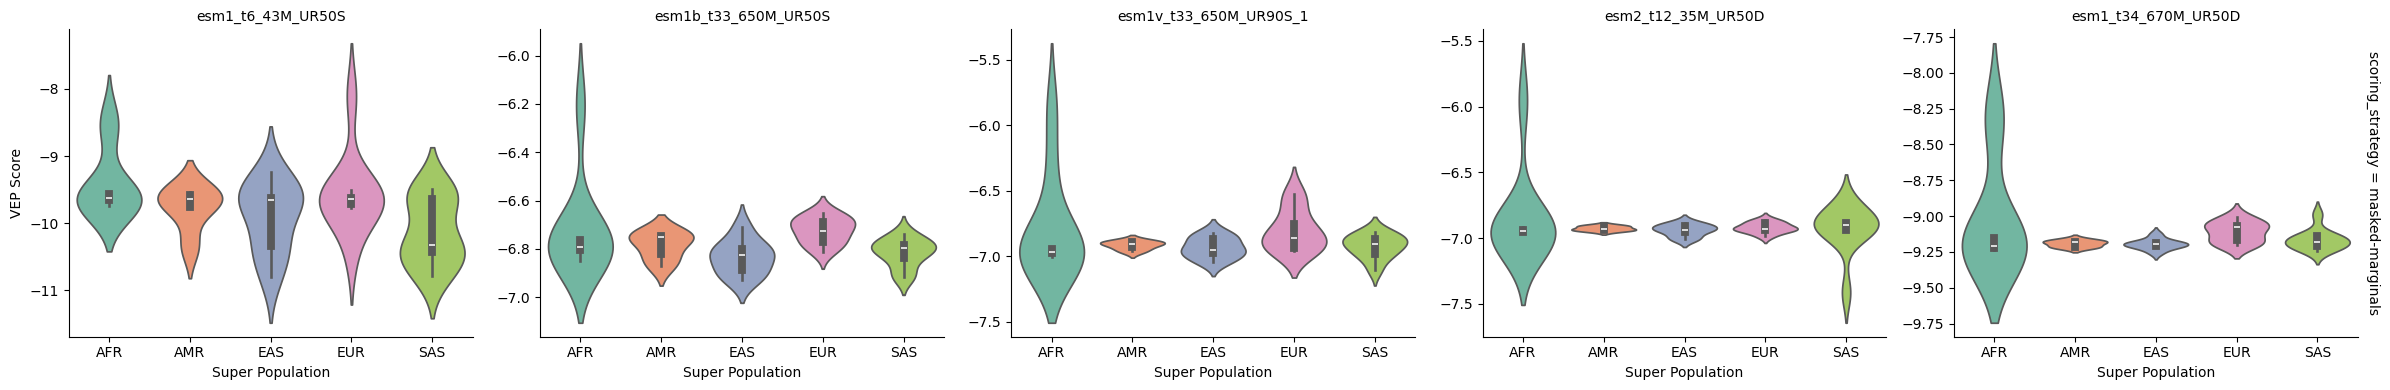

In [34]:
fig = va.plot_population_vep_violin_unweighted(hbb, 
                                               mutant=top_mutants.index[0], 
                                               min_freq=0)

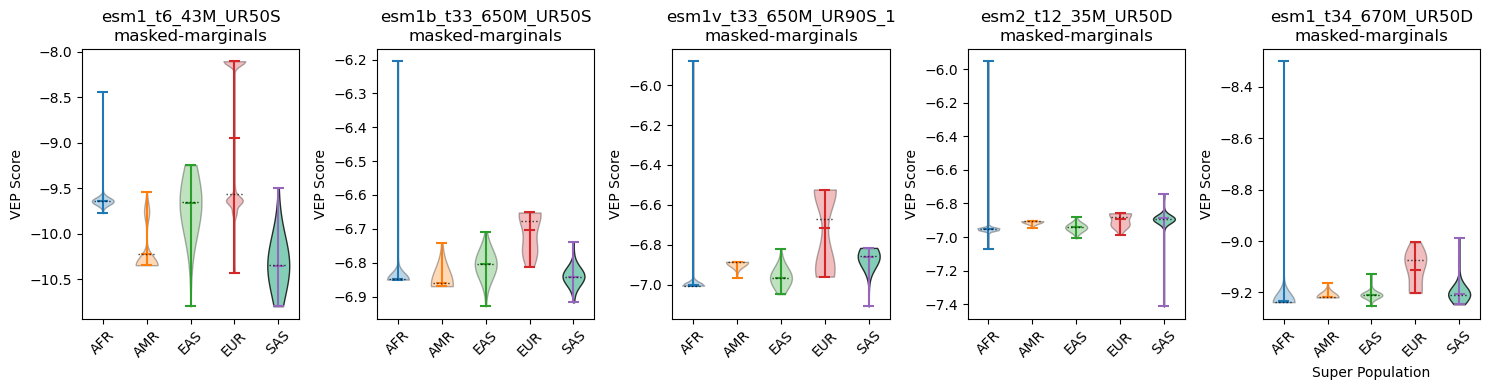

In [35]:
fig = va.plot_population_vep_violin_weighted(hbb, 
                                             mutant=top_mutants.index[0], 
                                               freq_col = 'top_superpop_freq',     
                                               min_freq=0)

### VEP by superpopulation (weighted by ALL haplotype frequencies)

In [69]:
# Get frequencies for every population (or superpopulation), not just the top one per haplotype
hbb_freq = va.create_vep_frequency_df(hbb, 
                                    pop_col= "Super Population")

(117000, 7)


In [70]:
hbb_freq.loc[hbb_freq['mutant']==hbb_mmr['mutant'].unique()[0]].dropna(subset=['frequency','VEP']).sort_values(by=['VEP','frequency'], ascending=[True,False]).groupby(['model_location','scoring_strategy','mutant']).head(1)

,haplotype,model_location,scoring_strategy,mutant,VEP,frequency,Super Population
11511,ENSP00000390299:247R>C,esm1v_t33_650M_UR90S_1,wt-marginals,L300P,-9.956064,0.002982,EUR
4647,ENSP00000390299:293H>Q,esm1b_t33_650M_UR50S,wt-marginals,L300P,-8.446716,0.002269,AFR
1579,ENSP00000390299:361V>G,esm2_t12_35M_UR50D,wt-marginals,L300P,-7.221777,0.000756,AFR
23055,ENSP00000390299:146E>K,esm1v_t33_650M_UR90S_1,masked-marginals,L300P,-6.397397,0.001022,SAS
13279,ENSP00000390299:361V>G,esm2_t12_35M_UR50D,masked-marginals,L300P,-4.396154,0.000756,AFR
16347,ENSP00000390299:293H>Q,esm1b_t33_650M_UR50S,masked-marginals,L300P,-4.363639,0.002269,AFR
17803,ENSP00000390299:288E>V,esm1_t34_670M_UR50D,masked-marginals,L300P,-2.983606,0.057637,AMR
6103,ENSP00000390299:288E>V,esm1_t34_670M_UR50D,wt-marginals,L300P,-2.823746,0.057637,AMR
8287,"ENSP00000390299:300L>R,400E>D",esm1_t6_43M_UR50S,wt-marginals,L300P,0.099747,0.000992,EAS
21027,"ENSP00000390299:125R>H,331G>R,400E>D",esm1_t6_43M_UR50S,masked-marginals,L300P,0.534792,0.001022,SAS


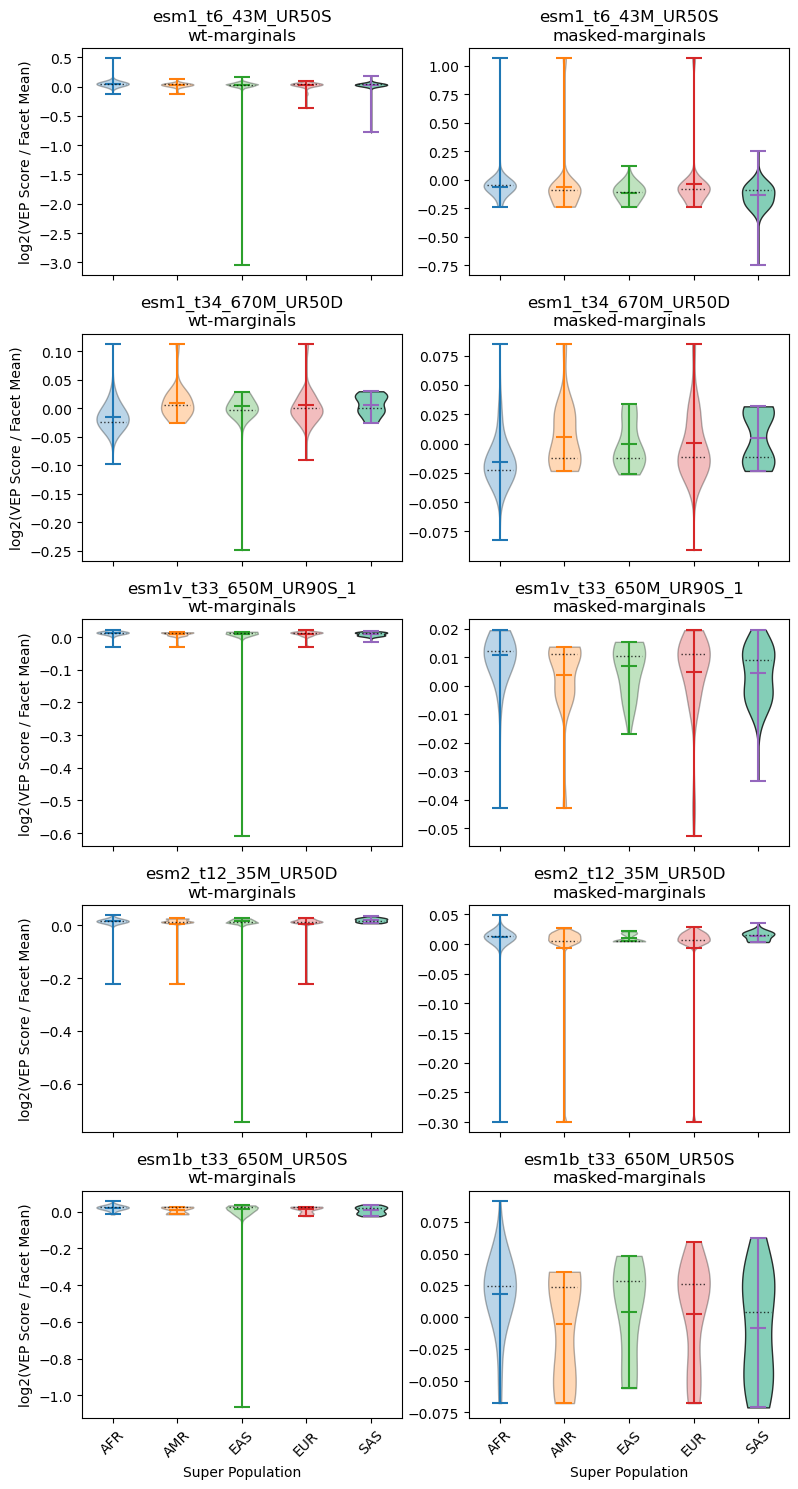

In [71]:
fig = va.plot_population_vep_violin_weighted(hbb_freq,
                                             top_pop_col='Super Population',
                                             mutant=hbb_mmr['mutant'].unique()[0], 
                                             min_freq=0, 
                                             log_fold_change=True)